# 01 · Synthetic neutral footprint — *hello world*

The minimal end-to-end call: feed FFP-style inputs for a **near-neutral** surface
layer to `lagranged.compute_footprint`, plot the normalized footprint density with
its 50/80/90 % cumulative source-area contours, and read off the along-wind peak
`x_peak`.

> Particles are released backward from the tower and their ground *touchdowns*
> build the footprint. Counts here are kept small so the notebook runs in CI; bump
> `n_particles` and lower `rebound_height` toward `z0` for a production footprint.

In [1]:
%matplotlib inline
import warnings

import matplotlib.pyplot as plt

import lagranged as lg

# Without measured tower turbulence the model falls back to MOST parameterizations
# and warns; that is expected here and is the subject of notebook 05.
warnings.filterwarnings("ignore", message="No measured TowerTurbulence")

print("lagranged", lg.__version__)

lagranged 0.2.0


## Inputs and accumulation grid

`FootprintInputs` carries the *physics* (one averaging period); `DomainGrid`
carries the *geometry* (a rectangular grid in the upwind model frame, receptor at
the origin, `+x` pointing upwind). A large negative Obukhov length `L` is
effectively neutral.

In [2]:
grid = lg.DomainGrid(nx=80, ny=80, dx=3.0, dy=3.0, x0=-90.0, y0=-120.0)

result = lg.compute_footprint(
    zm=3.0,        # measurement height [m]
    z0=0.03,       # roughness length [m]
    d=0.2,         # displacement height [m]
    L=-10_000.0,   # Obukhov length [m] -> effectively neutral
    ustar=0.35,    # friction velocity [m s-1]
    umean=2.4,     # mean wind speed at zm [m s-1]
    wind_dir=210.0,
    h=1000.0,      # boundary-layer height [m]
    sigma_v=0.6,   # lateral velocity std dev [m s-1]
    grid=grid,
    n_particles=800,
    seed=42,
    # Kept fast for CI: a raised surface-contact height and short integration time
    # keep the adaptive step out of the stiff near-z0 regime.
    rebound_height=0.5,
    t_max=120.0,
)

integral = float(result.density.sum()) * grid.dx * grid.dy
print(f"touchdowns = {result.n_touchdowns}")
print(f"x_peak     = {result.x_peak:.1f} m   (along-wind peak of the footprint)")
print(f"mc_noise   = {result.mc_noise:.3f}   (Monte-Carlo relative noise)")
print(f"integral   = {integral:.6f}   (density integrates to 1)")

touchdowns = 377
x_peak     = 25.5 m   (along-wind peak of the footprint)
mc_noise   = 0.066   (Monte-Carlo relative noise)
integral   = 1.000000   (density integrates to 1)


## Plot the footprint

`plot_footprint` draws the density as a `pcolormesh`; `plot_contours` overlays the
cumulative source-area iso-levels. Neither calls `plt.show()`, so they compose
onto an Axes you control.

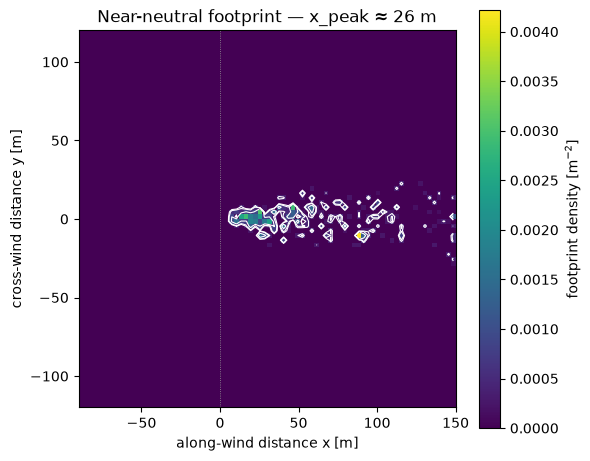

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
lg.plot_footprint(result, ax=ax)
lg.plot_contours(result, ax=ax, colors="white", linewidths=0.8)
ax.axvline(0.0, color="0.6", lw=0.6, ls=":")  # receptor (tower) at x = 0
ax.set_title(f"Near-neutral footprint — x_peak ≈ {result.x_peak:.0f} m")
fig.tight_layout()
plt.show()

The bright lobe sits **upwind** of the tower (positive `x`); the white rings are
the 50/80/90 % source areas. `x_peak` marks where the crosswind-integrated
footprint `f(x) = ∫ f dy` peaks — the most influential upwind distance for this
period.

Next: [`02_stability_sweep`](02_stability_sweep.ipynb) varies stability to show the
footprint contracting and expanding.